Open the file 'BedMachineGreenland_v5_20km_resolution_DatF.csv' using pandas, plot the surface elevation using plotly (try out other variables as well). Information about units can be found in 'BedMachineGreenland_v5_20km_resolution_DatF_metadata.txt'

In [3]:
# open csv file and make a 3d plot of the surface using plotly (try out the other variables as well)

import pandas as pd
# import plotly.graph_objects as go

df = pd.read_csv('../BedMachineGreenland_v5_20km_resolution_DatF.csv')

pivoted = df.pivot(index='y', columns='x', values='surface')

x = pivoted.columns    
y = pivoted.index
surface = pivoted.values

# fig = go.Figure(data=[go.Surface(
#     x=x,
#     y=y,
#     z=surface,
#     colorscale='tempo_r',
#     colorbar=dict(title='Surface Elevation (m)')
# )])

# fig.update_layout(
#     width=600,
#     height=600,
#     xaxis_title="X (m)",
#     yaxis_title="Y (m)"
#     )

# fig.show()

The sea level rise potential of the Greenland Ice Sheet is the height by which the global sea level would rise if the whole ice sheet would melt.

$slr = \frac{V_{ice} \cdot \rho_{ice}}{\rho_{water} \cdot A_{ocean}}$ 

The density of water is 1000 kg/m^3, of glaicer ice 917 km/m^3 and the global ocean area is 3.61e14 m^2. (or find from google or copilot)

Calculate the $\textit{slr}$ potential in 3 ways:

1. use only python loops
2. use numpy
3. use numba to speed up your loop function
4. ?

Use 'time' to compare the runtime of each approach (and plot).

Tip: pay attention to the grid resolution when calculating the ice volume

In [4]:
import numpy as np
import numba
import time
import matplotlib.pyplot as plt

pivoted = df.pivot(index='y', columns='x', values='thickness')
thickness = pivoted.values

cell_area = 20e3 * 20e3  # 20 km x 20 km grid cells
rho_i = 917  # density of ice in kg/m^3
rho_w = 1000  # density of water in kg/m^3
A_ocean = 3.61e14  # surface area of the oceans in m^2

# calculate ice volume with loops

def compute_slr_loop(thickness, cell_area=cell_area, rho_i=rho_i, rho_w=rho_w, A_ocean=A_ocean):
    total_volume = 0.0
    nrows, ncols = thickness.shape
    for i in range(nrows):
        for j in range(ncols):
            total_volume += thickness[i, j] * cell_area
    return (total_volume*rho_i)/(rho_w*A_ocean)

print(compute_slr_loop(thickness))

# use numpy

def compute_slr_numpy(thickness, cell_area=cell_area, rho_i=rho_i, rho_w=rho_w, A_ocean=A_ocean):
    return (np.sum(thickness * cell_area)*rho_i)/(rho_w*A_ocean)

print(compute_slr_numpy(thickness))

# use numba to speed up the loop calculation

@numba.njit(parallel=False)
def compute_slr_numba(thickness, cell_area=cell_area, rho_i=rho_i, rho_w=rho_w, A_ocean=A_ocean):
    total_volume = 0.0
    nrows, ncols = thickness.shape
    for i in numba.prange(nrows):
        for j in numba.prange(ncols):
            total_volume += thickness[i, j] * cell_area
    return (total_volume*rho_i)/(rho_w*A_ocean)

print(compute_slr_numba(thickness))

def compute_slr_pandas():
    total_volume = (df['thickness'] * cell_area).sum()
    return (total_volume * rho_i) / (rho_w * A_ocean)

print(compute_slr_pandas())

7.591178364484082
7.591178364484085
7.591178364484082
7.591178364484085


Timing the three methods:
Loop method: 1.76717 seconds
Numpy method: 0.00900 seconds
Numba method: 0.00500 seconds
Pandas method: 0.05302 seconds

Sea Level Rise Results
Pure Python: 7.591e+00 m
NumPy:       7.591e+00 m
Numba:       7.591e+00 m
Pandas:      7.591e+00 m


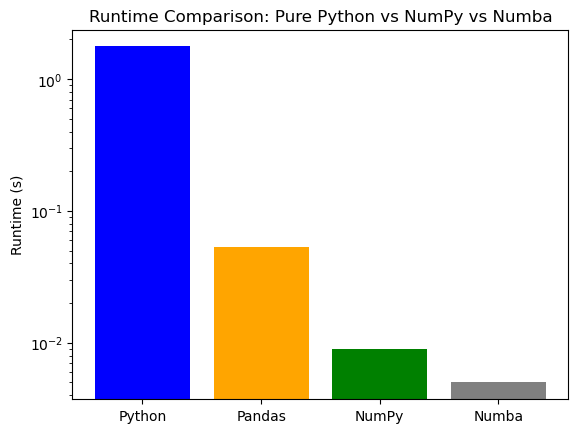

In [ ]:
# time the three methods

def time_function(func, *args):
    start_time = time.time()
    for i in range(1000):  # warm-up runs
        result = func(*args)
    end_time = time.time()
    return result, end_time - start_time

print("Timing the three methods:")
loop_result, loop_time = time_function(compute_slr_loop, thickness, cell_area, rho_i, rho_w, A_ocean)
print(f"Loop method: {loop_time:.5f} seconds")
numpy_result, numpy_time = time_function(compute_slr_numpy, thickness, cell_area, rho_i, rho_w, A_ocean)
print(f"Numpy method: {numpy_time:.5f} seconds")
_, _ = time_function(compute_slr_numba, thickness, cell_area, rho_i, rho_w, A_ocean)  
numba_result, numba_time = time_function(compute_slr_numba, thickness, cell_area, rho_i, rho_w, A_ocean)
print(f"Numba method: {numba_time:.5f} seconds")
pandas_result, pandas_time = time_function(compute_slr_pandas)
print(f"Pandas method: {pandas_time:.5f} seconds")


print("\nSea Level Rise Results")
print(f"Pure Python: {loop_result:.3e} m")
print(f"NumPy:       {numpy_result:.3e} m")
print(f"Numba:       {numba_result:.3e} m")
print(f"Pandas:      {pandas_result:.3e} m")

methods = ["Python", "Pandas", "NumPy", "Numba"]
times = [loop_time, pandas_time, numpy_time, numba_time]


plt.bar(methods, times, color=['blue', 'orange', 'green', 'grey'])
plt.ylabel("Runtime (s)")
plt.title("Runtime Comparison: Pure Python vs NumPy vs Numba")
plt.yscale('log')
